In [1]:
import pandas as pd
pd.set_option('display.max_rows', 10000)

## 1. Occurrences Data - used for map

In [3]:
occur_df = pd.read_csv("AggregatedData_AustralianSpeciesOccurrences_1.1.2023-06-13.csv")

In [4]:
occur_df.shape

(11619897, 13)

In [342]:
occur_df.isna().sum()

year                       0
basisOfRecord              0
stateTerritory       1089289
ibraRegion           1088674
imcraRegion         10509712
forest2018Status           0
forest2013Status           0
capadStatus                0
epbcStatus                 0
griisStatus                0
speciesID                  0
speciesName                0
occurrenceCount            0
dtype: int64

In [78]:
occur_df.groupby('year').size().reset_index(drop = False)

,year,0
0,1900,15468
1,1901,9334
2,1902,8741
3,1903,10888
4,1904,9350
5,1905,9053
6,1906,9741
7,1907,9243
8,1908,9202
9,1909,11331


In [18]:
# occur_df_2022 = occur_df.query("year == 2022")

In [29]:
occur_df_2022.head()

,year,basisOfRecord,stateTerritory,ibraRegion,imcraRegion,forest2018Status,forest2013Status,capadStatus,epbcStatus,griisStatus,speciesID,speciesName,occurrenceCount
11317553,2022,HUMAN_OBSERVATION,Ashmore and Cartier Islands,Indian Tropical Islands,NaN,non-forest,non-forest,PA,Not listed,Native,NZOR-6-24112,Gallirallus philippensis,1
11317554,2022,HUMAN_OBSERVATION,Ashmore and Cartier Islands,Indian Tropical Islands,NaN,non-forest,non-forest,PA,Not listed,Native,https://biodiversity.org.au/afd/taxa/00cf9ec9-...,Anous stolidus,2
11317555,2022,HUMAN_OBSERVATION,Ashmore and Cartier Islands,Indian Tropical Islands,NaN,non-forest,non-forest,PA,Not listed,Native,https://biodiversity.org.au/afd/taxa/13a31834-...,Onychoprion fuscatus,1
11317556,2022,HUMAN_OBSERVATION,Ashmore and Cartier Islands,Indian Tropical Islands,NaN,non-forest,non-forest,PA,Not listed,Native,https://biodiversity.org.au/afd/taxa/1441c509-...,Thalasseus bergii,1
11317557,2022,HUMAN_OBSERVATION,Ashmore and Cartier Islands,Indian Tropical Islands,NaN,non-forest,non-forest,PA,Not listed,Native,https://biodiversity.org.au/afd/taxa/31a2070b-...,Sula leucogaster,1


In [63]:
occur_df_2022.groupby(['speciesName', 'ibraRegion']).agg({"occurrenceCount": "sum"}).reset_index().sort_values("occurrenceCount")

,speciesName,ibraRegion,occurrenceCount
97664,Solanum chippendalei,Tanami,1
46912,Gazania krebsiana,South East Coastal Plain,1
46913,Gazania linearis,Cobar Peneplain,1
46914,Gazania linearis,Eyre Yorke Block,1
46916,Gazania linearis,Geraldton Sandplains,1
...,...,...,...
76165,Osphranter rufus,Murray Darling Depression,1994
81287,Phascolarctos cinereus,South Eastern Queensland,2007
5155,Alternanthera denticulata,Riverina,2069
91193,Rattus fuscipes,Sydney Basin,2272


## 2. Conservation Status

In [46]:
cons_status = pd.read_csv("27082025-093637-report.csv")

In [47]:
cons_status.head()

,TaxonID,ScientificName,CommonName,EPBCThreatStatus,EPBCThreatenedSpeciesListedName,EPBCThreatenedSpeciesDateEffective,ConservationAdvice,Kingdom,Family,AustralianCapitalTerritory,...,WesternAustralia,AshmoreandCartierIslands,Cocos(Keeling)Islands,ChristmasIsland,CoralSeaIslands,JervisBayTerritory,NorfolkIsland,HeardandMcDonaldIslands,AustralianAntarcticTerritory,CommonwealthMarineArea
0,66785,Abebaioscia troglodytes,Pannikin Plains Cave Isopod,NaN,NaN,NaN,NaN,Animalia,Philosciidae,NaN,...,Present,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93331,Abrodictyum obscurum,,NaN,NaN,NaN,NaN,Plantae,Hymenophyllaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8929,Abutilon fraseri,Dwarf Lantern-flower,NaN,NaN,NaN,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27797,Abutilon julianae,Norfolk Island Abutilon,Critically Endangered,Abutilon julianae,25-Nov-03,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Endemic,NaN,NaN,NaN
4,2204,Abutilon malvifolium,"Mallow-leaf Lantern-flower, Bastard Marshmallow",NaN,NaN,NaN,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
cons_status['EPBCThreatStatus'] = cons_status['EPBCThreatStatus'].fillna("Present")

In [100]:
cons_status.head()

,TaxonID,ScientificName,CommonName,EPBCThreatStatus,EPBCThreatenedSpeciesListedName,EPBCThreatenedSpeciesDateEffective,ConservationAdvice,Kingdom,Family,AustralianCapitalTerritory,...,WesternAustralia,AshmoreandCartierIslands,Cocos(Keeling)Islands,ChristmasIsland,CoralSeaIslands,JervisBayTerritory,NorfolkIsland,HeardandMcDonaldIslands,AustralianAntarcticTerritory,CommonwealthMarineArea
0,66785,Abebaioscia troglodytes,Pannikin Plains Cave Isopod,Present,NaN,NaN,NaN,Animalia,Philosciidae,NaN,...,Present,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93331,Abrodictyum obscurum,,Present,NaN,NaN,NaN,Plantae,Hymenophyllaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8929,Abutilon fraseri,Dwarf Lantern-flower,Present,NaN,NaN,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27797,Abutilon julianae,Norfolk Island Abutilon,Critically Endangered,Abutilon julianae,25-Nov-03,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Endemic,NaN,NaN,NaN
4,2204,Abutilon malvifolium,"Mallow-leaf Lantern-flower, Bastard Marshmallow",Present,NaN,NaN,NaN,Plantae,Malvaceae,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
cons_status.EPBCThreatStatus.value_counts()

Present                   2823
Endangered                 839
Vulnerable                 783
Critically Endangered      426
Extinct                    102
Conservation Dependent       7
Extinct in the wild          1
Name: EPBCThreatStatus, dtype: int64

In [133]:
df = occur_df.merge(cons_status[['ScientificName','EPBCThreatStatus', "CommonName", "Kingdom"]], left_on = "speciesName", right_on = "ScientificName")

In [134]:
df[df["EPBCThreatStatus"].notnull()].EPBCThreatStatus.value_counts()

Present                   1180658
Vulnerable                 128753
Endangered                  64304
Critically Endangered       26162
Conservation Dependent       1163
Extinct                       433
Extinct in the wild            21
Name: EPBCThreatStatus, dtype: int64

In [135]:
df.head()

,year,basisOfRecord,stateTerritory,ibraRegion,imcraRegion,forest2018Status,forest2013Status,capadStatus,epbcStatus,griisStatus,speciesID,speciesName,occurrenceCount,ScientificName,EPBCThreatStatus,CommonName,Kingdom
0,1900,HUMAN_OBSERVATION,New South Wales,Australian Alps,NaN,forest,forest,PA,Critically Endangered,Native,https://biodiversity.org.au/afd/taxa/1a3bc394-...,Pseudophryne corroboree,3,Pseudophryne corroboree,Critically Endangered,Southern Corroboree Frog,Animalia
1,1900,HUMAN_OBSERVATION,New South Wales,Australian Alps,NaN,forest,non-forest,PA,Critically Endangered,Native,https://biodiversity.org.au/afd/taxa/1a3bc394-...,Pseudophryne corroboree,1,Pseudophryne corroboree,Critically Endangered,Southern Corroboree Frog,Animalia
2,1900,HUMAN_OBSERVATION,New South Wales,Australian Alps,NaN,non-forest,forest,PA,Critically Endangered,Native,https://biodiversity.org.au/afd/taxa/1a3bc394-...,Pseudophryne corroboree,1,Pseudophryne corroboree,Critically Endangered,Southern Corroboree Frog,Animalia
3,1900,HUMAN_OBSERVATION,New South Wales,Australian Alps,NaN,non-forest,non-forest,PA,Critically Endangered,Native,https://biodiversity.org.au/afd/taxa/1a3bc394-...,Pseudophryne corroboree,1,Pseudophryne corroboree,Critically Endangered,Southern Corroboree Frog,Animalia
4,1950,HUMAN_OBSERVATION,New South Wales,Australian Alps,NaN,forest,non-forest,PA,Critically Endangered,Native,https://biodiversity.org.au/afd/taxa/1a3bc394-...,Pseudophryne corroboree,1,Pseudophryne corroboree,Critically Endangered,Southern Corroboree Frog,Animalia


In [136]:
df2 = (df[df["EPBCThreatStatus"]
          .notnull()]
       .groupby(["year","stateTerritory", "ibraRegion", "ScientificName", "CommonName", "Kingdom", "griisStatus", "capadStatus", "EPBCThreatStatus"])
       ["occurrenceCount"]
       .sum()
       .reset_index()
       .query("Kingdom == 'Animalia'")

In [137]:
df2.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount
0,1900,New South Wales,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1
2,1900,New South Wales,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6
5,1900,New South Wales,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2
6,1900,New South Wales,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1
8,1900,New South Wales,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3


In [148]:
df2.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount
0,1900,New South Wales,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1
2,1900,New South Wales,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6
5,1900,New South Wales,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2
6,1900,New South Wales,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1
8,1900,New South Wales,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3


In [155]:
df2.query('CommonName == "Koala"').groupby(["year", "CommonName"]).agg({"occurrenceCount": "sum"}).reset_index()

,year,CommonName,occurrenceCount
0,1900,Koala,153
1,1901,Koala,6
2,1904,Koala,1
3,1905,Koala,2
4,1907,Koala,3
5,1908,Koala,2
6,1909,Koala,1
7,1910,Koala,8
8,1911,Koala,2
9,1912,Koala,1


In [183]:
df2.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount
0,1900,New South Wales,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1
2,1900,New South Wales,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6
5,1900,New South Wales,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2
6,1900,New South Wales,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1
8,1900,New South Wales,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3


In [184]:
## save to csv
df2.to_csv('wildlife_occurrences_with_location_end_status_v1.csv', index=False)

In [177]:
agg_2023 = df2.query("year == 2022 and griisStatus == 'Native'").groupby(["year","CommonName", "ScientificName", "EPBCThreatStatus"])["occurrenceCount"].sum().reset_index().sort_values(["year", "occurrenceCount"], ascending = False)
# get list of present and endangered animals 
print(list(agg_2023.query("EPBCThreatStatus == 'Present'")["CommonName"].head(30)))
print(list(agg_2023.query("EPBCThreatStatus == 'Endangered'")["CommonName"].head(20)))

['Rabbit, European Rabbit', 'Red Fox, Fox', 'Koala', 'Eastern Grey Kangaroo', 'Swamp Wallaby', 'Short-beaked Echidna', 'Western Grey Kangaroo', 'Red Kangaroo', 'Bare-nosed Wombat, Common Wombat', 'Silver Gull', 'Yellow-tailed Black-Cockatoo', 'Platypus', 'Southern Long-nosed Bandicoot', 'Brown-striped Frog, Striped Marsh Frog', 'Eastern Long-necked Turtle', 'Cane Toad', 'Agile Antechinus', 'Diamond Python', 'Bush Stone-curlew', 'Murray Turtle, Macquarie Tortoise', 'Scarlet Robin', 'Great Egret, White Egret', 'Yellow-footed Antechinus', 'Rainbow Bee-eater', 'White-bellied Sea-Eagle', 'Glossy Black-Cockatoo', 'Burrowing Bettong', 'Yellow-bellied Glider', 'Brown Treecreeper', 'Flame Robin']
['Gang-gang Cockatoo', 'Greater Glider (southern and central)', 'Blue Mountains Water Skink', 'Southern Cassowary', 'Large-eared Pied Bat, Large Pied Bat', 'Long-footed Potoroo', "Baudin's Cockatoo, Baudin's Black-Cockatoo, Long-billed Black-cockatoo", 'Bridled Nail-tail Wallaby, Bridled Nailtail Walla

In [178]:
agg_2023.query("EPBCThreatStatus == 'Present'").head(30).reset_index(drop = True)

,year,CommonName,ScientificName,EPBCThreatStatus,occurrenceCount
0,2022,"Rabbit, European Rabbit",Oryctolagus cuniculus,Present,5754
1,2022,"Red Fox, Fox",Vulpes vulpes,Present,5485
2,2022,Koala,Phascolarctos cinereus,Present,4897
3,2022,Eastern Grey Kangaroo,Macropus giganteus,Present,3734
4,2022,Swamp Wallaby,Wallabia bicolor,Present,3199
5,2022,Short-beaked Echidna,Tachyglossus aculeatus,Present,2894
6,2022,Western Grey Kangaroo,Macropus fuliginosus,Present,2280
7,2022,Red Kangaroo,Osphranter rufus,Present,2113
8,2022,"Bare-nosed Wombat, Common Wombat",Vombatus ursinus,Present,1856
9,2022,Silver Gull,Chroicocephalus novaehollandiae,Present,1398


In [179]:
agg_2023.query("EPBCThreatStatus == 'Endangered'").head(30).reset_index(drop = True)

,year,CommonName,ScientificName,EPBCThreatStatus,occurrenceCount
0,2022,Gang-gang Cockatoo,Callocephalon fimbriatum,Endangered,1025
1,2022,Greater Glider (southern and central),Petauroides volans,Endangered,646
2,2022,Blue Mountains Water Skink,Eulamprus leuraensis,Endangered,182
3,2022,Southern Cassowary,Casuarius casuarius,Endangered,134
4,2022,"Large-eared Pied Bat, Large Pied Bat",Chalinolobus dwyeri,Endangered,87
5,2022,Long-footed Potoroo,Potorous longipes,Endangered,83
6,2022,"Baudin's Cockatoo, Baudin's Black-Cockatoo, Lo...",Zanda baudinii,Endangered,71
7,2022,"Bridled Nail-tail Wallaby, Bridled Nailtail Wa...",Onychogalea fraenata,Endangered,65
8,2022,Spectacled Flying-fox,Pteropus conspicillatus,Endangered,57
9,2022,"Common Greenshank, Greenshank",Tringa nebularia,Endangered,55


In [164]:
list(agg_2023.query("EPBCThreatStatus == 'Present'").head()["CommonName"])

['Rabbit, European Rabbit',
 'Red Fox, Fox',
 'Koala',
 'Eastern Grey Kangaroo',
 'Swamp Wallaby']

In [180]:
agg_2023.head()

,year,CommonName,ScientificName,EPBCThreatStatus,occurrenceCount
403,2022,"Rabbit, European Rabbit",Oryctolagus cuniculus,Present,5754
406,2022,"Red Fox, Fox",Vulpes vulpes,Present,5485
269,2022,Koala,Phascolarctos cinereus,Present,4897
165,2022,Eastern Grey Kangaroo,Macropus giganteus,Present,3734
506,2022,Swamp Wallaby,Wallabia bicolor,Present,3199


In [132]:
schema = 'critterai'

#year	stateTerritory	ibraRegion	ScientificName	CommonName	Kingdom	griisStatus	capadStatus	EPBCThreatStatus	occurrenceCount

query = (f"""
--create schema
CREATE SCHEMA IF NOT EXISTS{schema};

CREATE TABLE IF NOT EXISTS {schema}.wildlife_occurrences_with_location_end_status (
    year DATE,
    stateTerritory VARCHAR,
    ibraRegion VARCHAR,
    --- need to add latitude and longitude
    ScientificName VARCHAR,
    CommonName VARCHAR,
    Kingdom VARCHAR,
    griisStatus VARCHAR,
    capadStatus VARCHAR,
    ENBCThreatStatus VARCHAR,
    occurrenceCount INT

""")

In [195]:
pip install fiona
# pip install geopandas

SyntaxError: invalid syntax (3722328929.py, line 1)

In [196]:
pip install fiona

  Using cached fiona-1.10.1-cp39-cp39-macosx_10_15_x86_64.whl (16.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [197]:
import fiona
from shapely.geometry import shape
import csv

In [202]:
with fiona.open(shapefile) as src:
    # Print schema (shows field names and types)
    print("Schema fields:", src.schema["properties"].keys())

    # Peek at first record's attributes
    first_feature = next(iter(src))
    print("First feature properties:", first_feature["properties"])

Schema fields: dict_keys(['OBJECTID', 'IBRA_REG_N', 'IBRA_REG_C', 'IBRA_REG_1', 'STATE', 'SHAPE_AREA', 'SHAPE_LEN'])
First feature properties: fiona.Properties(OBJECTID=10241, IBRA_REG_N='Australian Alps', IBRA_REG_C='AUA', IBRA_REG_1=3, STATE='ACT', SHAPE_AREA=543790472.096, SHAPE_LEN=559000.041145)


In [212]:
pip install pyproj

  Using cached pyproj-3.6.1-cp39-cp39-macosx_10_9_x86_64.whl (6.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [213]:
import fiona
from shapely.geometry import shape
from shapely.ops import transform
from pyproj import Transformer
import csv

# Input shapefile
shapefile = "IBRARegion_Aust70.shp"

# Output CSV
output_csv = "ibra7_centroids_latlon.csv"

with fiona.open(shapefile) as src:
    # Build transformer from source CRS to WGS84 (EPSG:4326)
    transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)

    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["IBRA_REG_N", "STATE", "lat", "lon"])
        
        for feature in src:
            geom = shape(feature["geometry"])
            centroid = geom.centroid

            # Reproject centroid to lat/lon
            lon, lat = transformer.transform(centroid.x, centroid.y)

            reg_name = feature["properties"]["IBRA_REG_N"]
            state = feature["properties"]["STATE"]

            writer.writerow([reg_name, state, lat, lon])

print(f"✅ Saved centroids in proper lat/lon to {output_csv}")

✅ Saved centroids in proper lat/lon to ibra7_centroids_latlon.csv


In [296]:
df2.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount
0,1900,NSW,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1
2,1900,NSW,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6
5,1900,NSW,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2
6,1900,NSW,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1
8,1900,NSW,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3


In [291]:
state_map = {
    "New South Wales": "NSW",
    "Victoria": "VIC",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Western Australia": "WA",
    "Tasmania": "TAS",
    "Australian Capital Territory": "ACT",
    "Northern Territory": "NT",
    "Jervis Bay Territory": "JBT",
    "External Territories": "EXT"
}

# Replace full names with abbreviations
df2["stateTerritory"] = df2["stateTerritory"].replace(state_map)

In [216]:
ipra7_lat_long =  pd.read_csv("ibra7_centroids_latlon.csv")

In [217]:
ipra7_lat_long.head()

,IBRA_REG_N,STATE,lat,lon
0,Australian Alps,ACT,-35.667875,148.909459
1,South Eastern Highlands,ACT,-35.434530,149.030591
2,Coral Sea,EXT,-18.202475,151.620450
3,Indian Tropical Islands,EXT,-11.742666,112.798183
4,Pacific Subtropical Islands,EXT,-29.931893,165.098390


In [292]:
df4 = df2.merge(
    ipra7_lat_long,
    left_on=["ibraRegion", "stateTerritory"],
    right_on=["IBRA_REG_N", "STATE"],
    how="left"   # left join so you don’t drop df2 rows if no match
)

# df4["CommonName_clean"] = (
#     df4["CommonName"]
#       .fillna("")
#       .astype(str)
#       .str.split(",")
#       .str[0]
#       .str.strip()
# )

In [343]:
df4 = pd.read_csv('wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv')
df4.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount,IBRA_REG_N,STATE,lat,lon,CommonName_clean
0,1900,NSW,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1,Australian Alps,NSW,-36.074960,148.469095,Platypus
1,1900,NSW,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6,Australian Alps,NSW,-36.074960,148.469095,Southern Corroboree Frog
2,1900,NSW,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2,Brigalow Belt South,NSW,-30.762574,149.581615,Australian Bustard
3,1900,NSW,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1,Brigalow Belt South,NSW,-30.762574,149.581615,Spotted Bowerbird
4,1900,NSW,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3,Brigalow Belt South,NSW,-30.762574,149.581615,Grey Snake


In [293]:
df4.query("year == 2022").head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount,IBRA_REG_N,STATE,lat,lon
452405,2022,Ashmore and Cartier Islands,Indian Tropical Islands,Anous stolidus,Common Noddy,Animalia,Native,PA,Present,2,NaN,NaN,NaN,NaN
452406,2022,Ashmore and Cartier Islands,Indian Tropical Islands,Fregata ariel,"Lesser Frigatebird, Least Frigatebird",Animalia,Native,PA,Present,2,NaN,NaN,NaN,NaN
452407,2022,Ashmore and Cartier Islands,Indian Tropical Islands,Fregata ariel,"Lesser Frigatebird, Least Frigatebird",Animalia,Native,not protected,Present,1,NaN,NaN,NaN,NaN
452408,2022,Ashmore and Cartier Islands,Indian Tropical Islands,Onychoprion fuscatus,Sooty Tern,Animalia,Native,PA,Present,1,NaN,NaN,NaN,NaN
452409,2022,Ashmore and Cartier Islands,Indian Tropical Islands,Phaethon lepturus,White-tailed Tropicbird,Animalia,Native,PA,Present,1,NaN,NaN,NaN,NaN


In [294]:
ipra7_lat_long.head()

,IBRA_REG_N,STATE,lat,lon
0,Australian Alps,ACT,-35.667875,148.909459
1,South Eastern Highlands,ACT,-35.434530,149.030591
2,Coral Sea,EXT,-18.202475,151.620450
3,Indian Tropical Islands,EXT,-11.742666,112.798183
4,Pacific Subtropical Islands,EXT,-29.931893,165.098390


In [295]:
df2.stateTerritory.value_counts()

NSW                            108408
QLD                             93120
VIC                             81236
SA                              56038
NT                              49139
WA                              44197
TAS                             19877
ACT                              5195
Ashmore and Cartier Islands       604
Unknown1                          544
Coral Sea Islands                  61
Name: stateTerritory, dtype: int64

In [234]:
## save to csv
df4.to_csv('wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv', index=False)

In [241]:
df4.groupby(["EPBCThreatStatus", "year"]).agg({"occurrenceCount": "sum"}).reset_index().sort_values("year")

,EPBCThreatStatus,year,occurrenceCount
47,Critically Endangered,1900,45
500,Vulnerable,1900,437
169,Endangered,1900,248
292,Extinct,1900,2
377,Present,1900,2356
501,Vulnerable,1901,90
48,Critically Endangered,1901,16
170,Endangered,1901,13
293,Extinct,1901,37
378,Present,1901,419


In [242]:
df4.query("year == 2022 and griisStatus == 'Native'").groupby(["year","CommonName", "ScientificName", "EPBCThreatStatus"])["occurrenceCount"].sum().reset_index().sort_values(["year", "occurrenceCount"], ascending = False)

,year,CommonName,ScientificName,EPBCThreatStatus,occurrenceCount
403,2022,"Rabbit, European Rabbit",Oryctolagus cuniculus,Present,5754
406,2022,"Red Fox, Fox",Vulpes vulpes,Present,5485
269,2022,Koala,Phascolarctos cinereus,Present,4897
165,2022,Eastern Grey Kangaroo,Macropus giganteus,Present,3734
506,2022,Swamp Wallaby,Wallabia bicolor,Present,3199
447,2022,Short-beaked Echidna,Tachyglossus aculeatus,Present,2894
534,2022,Western Grey Kangaroo,Macropus fuliginosus,Present,2280
408,2022,Red Kangaroo,Osphranter rufus,Present,2113
34,2022,"Bare-nosed Wombat, Common Wombat",Vombatus ursinus,Present,1856
454,2022,Silver Gull,Chroicocephalus novaehollandiae,Present,1398


In [255]:
species_names = list(df4["ScientificName"].unique())

In [259]:
species_names[0:5]

['Ornithorhynchus anatinus',
 'Pseudophryne corroboree',
 'Ardeotis australis',
 'Chlamydera maculata',
 'Hemiaspis damelii']

In [261]:
import requests, time
import pandas as pd

# ---- If you already have an occurrences DF, set this and skip the example list below:
# occ_df = pd.json_normalize(resp["occurrences"])
# species_names = sorted(occ_df["scientificName"].dropna().unique())

# Demo list
# species_names = [
#     "Acanthopagrus butcheri",
#     "Pelecanus conspicillatus",
#     "Alectura lathami",
#     "Phylidonyris niger"  # add more if you like
# ]

species_names = list(df4["ScientificName"].unique())[0:20]

# Endpoints
REST_SUMMARY = "https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
REST_SEARCH   = "https://en.wikipedia.org/w/rest.php/v1/search/title"
ACTION_API    = "https://en.wikipedia.org/w/api.php"

HEADERS = {
    "Accept": "application/json",
    "User-Agent": "MonashDataProject/1.0 (contact: your-email@example.com)"
}

def get_rest_summary(title: str):
    """Try REST summary for a given title (handles redirects)."""
    r = requests.get(REST_SUMMARY.format(title=title), params={"redirect":"true"}, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    j = r.json()
    # 'type' can be 'standard', 'disambiguation', etc.
    extract = j.get("extract")
    thumb = (j.get("originalimage") or {}).get("source") or (j.get("thumbnail") or {}).get("source")
    return {"summary": extract, "image_url": thumb, "resolved_title": j.get("title"), "type": j.get("type")}

def search_best_title(query: str):
    """Use REST title search to find the best page title."""
    r = requests.get(REST_SEARCH, params={"q": query, "limit": 1}, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    data = r.json()
    # Some deployments use 'pages', some 'results'
    items = data.get("pages") or data.get("results") or []
    if not items:
        return None
    top = items[0]
    return top.get("title") or top.get("key")

def get_action_intro_and_image(title: str):
    """
    Fallback to MediaWiki action API:
    - exintro & explaintext for one-liner description
    - pageimages original for lead image
    """
    params = {
        "action": "query",
        "prop": "extracts|pageimages",
        "exintro": 1,
        "explaintext": 1,
        "piprop": "original",
        "redirects": 1,
        "titles": title,
        "format": "json"
    }
    r = requests.get(ACTION_API, params=params, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    j = r.json()
    pages = j.get("query", {}).get("pages", {})
    if not pages:
        return None
    page = next(iter(pages.values()))
    extract = page.get("extract")
    img = (page.get("original") or {}).get("source")
    return {"summary": extract, "image_url": img, "resolved_title": page.get("title")}

def fetch_wiki_row(name: str, sleep=0.2):
    """
    Try multiple strategies to get a one-liner + image for a scientific name.
    Returns dict with scientificName, summary, image_url.
    """
    # 1) Direct REST with scientific name
    for t in (name, name.replace(" ", "_")):
        out = get_rest_summary(t)
        if out and out.get("summary"):
            time.sleep(sleep); return {"scientificName": name, **out}

    # 2) REST search → summary
    best = search_best_title(name)
    if best:
        out = get_rest_summary(best)
        if out and out.get("summary"):
            time.sleep(sleep); return {"scientificName": name, **out}

    # 3) Fallback: MediaWiki action API
    for t in (best or name, name.replace(" ", "_")):
        out = get_action_intro_and_image(t)
        if out and out.get("summary"):
            time.sleep(sleep); return {"scientificName": name, **out}

    # Nothing found
    time.sleep(sleep)
    return {"scientificName": name, "summary": None, "image_url": None, "resolved_title": None}

# Run for all unique names
rows = [fetch_wiki_row(nm) for nm in species_names]
wiki_df = pd.DataFrame(rows, columns=["scientificName","summary","image_url","resolved_title"])
wiki_df.head()

# ---- If you want to left-join back to occurrence records:
# occ_enriched = occ_df.merge(wiki_df[["scientificName","summary","image_url"]], on="scientificName", how="left")
# print(occ_enriched.head())


,scientificName,summary,image_url,resolved_title
0,Ornithorhynchus anatinus,"The platypus, sometimes referred to as the duc...",https://upload.wikimedia.org/wikipedia/commons...,Platypus
1,Pseudophryne corroboree,The southern corroboree frog is a species of A...,https://upload.wikimedia.org/wikipedia/commons...,Southern corroboree frog
2,Ardeotis australis,The Australian bustard is a large ground-dwell...,https://upload.wikimedia.org/wikipedia/commons...,Australian bustard
3,Chlamydera maculata,"The spotted bowerbird is a sedentary, mid-size...",https://upload.wikimedia.org/wikipedia/commons...,Spotted bowerbird
4,Hemiaspis damelii,Hemiaspis damelii is a species of venomous sna...,None,Hemiaspis damelii


In [ ]:
import requests, time
import pandas as pd

# Example input — normally you'd extract both scientific + vernacular from ALA occurrences
species_records = [
    {"scientificName": "Acanthopagrus butcheri", "vernacularName": "Black Bream"},
    {"scientificName": "Pelecanus conspicillatus", "vernacularName": "Australian Pelican"},
    {"scientificName": "Alectura lathami", "vernacularName": "Australian Brush-turkey"},
    {"scientificName": "Phylidonyris niger", "vernacularName": "White-cheeked Honeyeater"}
]

REST_SUMMARY = "https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
REST_SEARCH   = "https://en.wikipedia.org/w/rest.php/v1/search/title"
ACTION_API    = "https://en.wikipedia.org/w/api.php"

HEADERS = {
    "Accept": "application/json",
    "User-Agent": "MonashDataProject/1.0 (contact: your-email@example.com)"
}

def get_rest_summary(title: str):
    """Try REST summary for a given title (handles redirects)."""
    r = requests.get(REST_SUMMARY.format(title=title), params={"redirect":"true"}, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    j = r.json()
    extract = j.get("extract")
    thumb = (j.get("originalimage") or {}).get("source") or (j.get("thumbnail") or {}).get("source")
    return {"summary": extract, "image_url": thumb, "resolved_title": j.get("title")}

def search_best_title(query: str):
    """Use REST title search to find the best page title."""
    r = requests.get(REST_SEARCH, params={"q": query, "limit": 1}, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    items = r.json().get("pages") or r.json().get("results") or []
    if not items:
        return None
    return items[0].get("title") or items[0].get("key")

def get_action_intro_and_image(title: str):
    """Fallback: MediaWiki action API."""
    params = {
        "action": "query",
        "prop": "extracts|pageimages",
        "exintro": 1,
        "explaintext": 1,
        "piprop": "original",
        "redirects": 1,
        "titles": title,
        "format": "json"
    }
    r = requests.get(ACTION_API, params=params, headers=HEADERS, timeout=15)
    if r.status_code != 200:
        return None
    pages = r.json().get("query", {}).get("pages", {})
    if not pages:
        return None
    page = next(iter(pages.values()))
    return {
        "summary": page.get("extract"),
        "image_url": (page.get("original") or {}).get("source"),
        "resolved_title": page.get("title")
    }

def fetch_wiki_row(record, sleep=0.2):
    """
    Try multiple strategies to get a one-liner + image.
    Order: scientific name → common name.
    """
    sci = record["scientificName"]
    com = record.get("vernacularName")

    for candidate in [sci, com]:
        if not candidate:
            continue
        # 1) Direct REST
        for t in (candidate, candidate.replace(" ", "_")):
            out = get_rest_summary(t)
            if out and out.get("summary"):
                time.sleep(sleep); return {"scientificName": sci, "vernacularName": com, **out}
        # 2) Search → REST
        best = search_best_title(candidate)
        if best:
            out = get_rest_summary(best)
            if out and out.get("summary"):
                time.sleep(sleep); return {"scientificName": sci, "vernacularName": com, **out}
        # 3) Action API
        out = get_action_intro_and_image(candidate)
        if out and out.get("summary"):
            time.sleep(sleep); return {"scientificName": sci, "vernacularName": com, **out}

    # Nothing found
    time.sleep(sleep)
    return {"scientificName": sci, "vernacularName": com, "summary": None, "image_url": None, "resolved_title": None}

# Run
rows = [fetch_wiki_row(rec) for rec in species_records]
wiki_df = pd.DataFrame(rows)
print(wiki_df)


In [279]:
pairs = (
    df4[["ScientificName", "CommonName_clean"]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={"CommonName_clean": "CommonName"})
)

In [280]:
pairs.head()

,ScientificName,CommonName
0,Ornithorhynchus anatinus,Platypus
1,Pseudophryne corroboree,Southern Corroboree Frog
2,Ardeotis australis,Australian Bustard
3,Chlamydera maculata,Spotted Bowerbird
4,Hemiaspis damelii,Grey Snake


In [283]:
# df4.to_csv('wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv', index=False)

In [284]:
# pairs.to_csv('animal_list_v1.csv', index=False)

In [282]:
# df4.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount,IBRA_REG_N,STATE,lat,lon,CommonName_clean
0,1900,NSW,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1,Australian Alps,NSW,-36.074960,148.469095,Platypus
1,1900,NSW,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6,Australian Alps,NSW,-36.074960,148.469095,Southern Corroboree Frog
2,1900,NSW,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2,Brigalow Belt South,NSW,-30.762574,149.581615,Australian Bustard
3,1900,NSW,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1,Brigalow Belt South,NSW,-30.762574,149.581615,Spotted Bowerbird
4,1900,NSW,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3,Brigalow Belt South,NSW,-30.762574,149.581615,Grey Snake


In [341]:
import requests, time
import pandas as pd
from typing import Optional

# 1) Clean common names
# df4["CommonName_clean"] = (
#     df4["CommonName"]
#       .fillna("")
#       .astype(str)
#       .str.split(",")
#       .str[0]
#       .str.strip()
# )

df4 = pd.read_csv('wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv')

# Unique (scientific, common) pairs
pairs = (
    df4[["ScientificName", "CommonName_clean"]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={"CommonName_clean": "CommonName"})
)

# 2) Wikipedia API helpers
REST_SUMMARY = "https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
HEADERS = {
    "Accept": "application/json",
    "User-Agent": "MonashDataProject/1.0 (contact: your-email@example.com)"
}

def _rest_summary(title: str):
    r = requests.get(
        REST_SUMMARY.format(title=title.replace(" ", "_")),
        params={"redirect": "true"},
        headers=HEADERS, timeout=15
    )
    if r.status_code != 200:
        return None
    j = r.json()
    return {
        "summary": j.get("extract"),
        "image_url": (j.get("originalimage") or {}).get("source")
                     or (j.get("thumbnail") or {}).get("source"),
        "resolved_title": j.get("title")
    }

def fetch_wiki(sci: str, com: Optional[str], sleep=0.2):
    for cand in [sci, com]:
        if not cand:
            continue
        out = _rest_summary(cand)
        if out and out.get("summary"):
            time.sleep(sleep)  # polite delay
            return out
    return {"summary": None, "image_url": None, "resolved_title": None}

# 3) Collect into a DataFrame
records = []
for row in pairs.itertuples(index=False):
    sci, com = row.ScientificName, row.CommonName
    wiki_info = fetch_wiki(sci, com)
    records.append({
        "ScientificName": sci,
        "CommonName": com,
        "WikiTitle": wiki_info["resolved_title"],
        "WikiSummary": wiki_info["summary"],
        "WikiImage": wiki_info["image_url"]
    })

wiki_df = pd.DataFrame(records)
wiki_df
# --- Optional: merge back to df4 ---
# df4 = df4.merge(wiki_df, on=["ScientificName", "CommonName"], how="left")


ReadTimeout: HTTPSConnectionPool(host='en.wikipedia.org', port=443): Read timed out. (read timeout=15)

In [304]:
import requests

sci = "Ornithorhynchus anatinus"
url = f"https://api.inaturalist.org/v1/taxa?q={sci}"
r = requests.get(url).json()
print(r["results"][0])

{'id': 43236, 'rank': 'species', 'rank_level': 10, 'iconic_taxon_id': 40151, 'ancestor_ids': [48460, 1, 2, 355675, 40151, 848316, 43233, 43234, 43235, 43236], 'is_active': True, 'name': 'Ornithorhynchus anatinus', 'parent_id': 43235, 'ancestry': '48460/1/2/355675/40151/848316/43233/43234/43235', 'extinct': False, 'default_photo': {'id': 100089852, 'license_code': None, 'attribution': '(c) Julien Rouard - Dreamtime Nature Photography, all rights reserved, uploaded by Julien Rouard - Dreamtime Nature Photography', 'url': 'https://static.inaturalist.org/photos/100089852/square.jpg', 'original_dimensions': {'height': 1365, 'width': 2048}, 'flags': [], 'attribution_name': 'Julien Rouard - Dreamtime Nature Photography', 'square_url': 'https://static.inaturalist.org/photos/100089852/square.jpg', 'medium_url': 'https://static.inaturalist.org/photos/100089852/medium.jpg'}, 'taxon_changes_count': 0, 'taxon_schemes_count': 4, 'observations_count': 3663, 'flag_counts': {'resolved': 1, 'unresolved'

In [319]:
import requests
import time
import pandas as pd
from typing import Optional
from urllib.parse import quote

# ---------------------------
# Config
# ---------------------------
INPUT_CSV = "wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv"
USER_AGENT = "MonashDataProject/1.0 (contact@example.com)"  # change to your email
SLEEP = 0.15  # polite delay between calls

HEADERS = {"Accept": "application/json", "User-Agent": USER_AGENT}

# ALA endpoints
ALA_AUTO        = "https://api.ala.org.au/species/search/auto"
ALA_SPECIES     = "https://api.ala.org.au/species/species/{}"        # {encoded GUID}
ALA_IMAGESEARCH = "https://api.ala.org.au/species/imageSearch/{}"    # {encoded GUID}

# Wikipedia (for one-liner text)
WIKI_SUMMARY    = "https://en.wikipedia.org/api/rest_v1/page/summary/{}"


# ---------------------------
# Helpers
# ---------------------------
def ala_find_guid(query: Optional[str]) -> Optional[str]:
    """Use ALA autocomplete to resolve a GUID for a taxon name."""
    if not query:
        return None
    r = requests.get(
        ALA_AUTO,
        params={"q": query, "idxType": "TAXON", "limit": 1},
        headers=HEADERS,
        timeout=20,
    )
    time.sleep(SLEEP)
    if r.status_code != 200:
        return None
    js = r.json() or {}
    results = js.get("autoCompleteList") or js.get("items") or js.get("results") or []
    if not results:
        return None
    return results[0].get("guid") or results[0].get("uid") or results[0].get("id")


def ala_species_details(guid: str) -> dict:
    """Fetch ALA species details (may include wikipediaUrl and other facts)."""
    url = ALA_SPECIES.format(quote(guid, safe=""))
    r = requests.get(url, headers=HEADERS, timeout=20)
    time.sleep(SLEEP)
    if r.status_code != 200:
        return {}
    return r.json() or {}


def ala_images_for_guid(guid: str) -> list[dict]:
    """Fetch images for a GUID via ALA imageSearch."""
    url = ALA_IMAGESEARCH.format(quote(guid, safe=""))
    r = requests.get(url, headers=HEADERS, timeout=20)
    time.sleep(SLEEP)
    if r.status_code != 200:
        return []
    js = r.json() or {}
    # service responses vary; try common keys
    return js.get("images") or js.get("results") or js.get("data") or []


def pick_best_image(images: list[dict]) -> Optional[str]:
    """Choose a good image URL from the imageSearch payload."""
    if not images:
        return None
    img = images[0]
    return (
        img.get("largeImageUrl")
        or img.get("imageUrl")
        or img.get("thumbnailUrl")
        or img.get("smallImageUrl")
    )


def wiki_summary_from_url(wiki_url: Optional[str]) -> Optional[str]:
    """If a Wikipedia URL is given, fetch its one-liner summary."""
    if not wiki_url:
        return None
    title = wiki_url.rsplit("/", 1)[-1]
    if not title:
        return None
    r = requests.get(
        WIKI_SUMMARY.format(title),
        params={"redirect": "true"},
        headers=HEADERS,
        timeout=15,
    )
    time.sleep(SLEEP)
    if r.status_code != 200:
        return None
    return (r.json() or {}).get("extract")


def wiki_summary_direct(name: Optional[str]) -> Optional[str]:
    """Fallback: call Wikipedia summary directly by a name (scientific or common)."""
    if not name:
        return None
    title = name.replace(" ", "_")
    r = requests.get(
        WIKI_SUMMARY.format(title),
        params={"redirect": "true"},
        headers=HEADERS,
        timeout=15,
    )
    time.sleep(SLEEP)
    if r.status_code != 200:
        return None
    return (r.json() or {}).get("extract")


def fetch_ala_record(scientific: str, common: Optional[str]) -> dict:
    """
    Resolve GUID via ALA (try scientific -> common),
    fetch images + details, and get a Wikipedia one-liner
    (using ALA's wikipediaUrl if present, otherwise direct by name).
    """
    guid = ala_find_guid(scientific) or ala_find_guid(common)
    if not guid:
        return {
            "ALA_GUID": None,
            "ALA_Image": None,
            "ALA_WikipediaUrl": None,
            "WikiSummary": None,
        }

    # Species details (for wiki link and other metadata if you want later)
    details = ala_species_details(guid)
    wiki_url = details.get("wikipediaUrl") or details.get("wikiUrl")

    # Images
    imgs = ala_images_for_guid(guid)
    best_img = pick_best_image(imgs)

    # One-liner: prefer ALA-provided wikiUrl; else query by name
    summary = wiki_summary_from_url(wiki_url) or wiki_summary_direct(scientific) or wiki_summary_direct(common)

    return {
        "ALA_GUID": guid,
        "ALA_Image": best_img,
        "ALA_WikipediaUrl": wiki_url,
        "WikiSummary": summary,
    }


# ---------------------------
# Main
# ---------------------------
# Load your data
df4 = pd.read_csv(INPUT_CSV)

# Clean common names (use first chunk before comma)
if "CommonName_clean" not in df4.columns:
    df4["CommonName_clean"] = (
        df4.get("CommonName", "")
        .fillna("")
        .astype(str)
        .str.split(",")
        .str[0]
        .str.strip()
    )

# Unique pairs to avoid duplicate lookups
pairs = (
    df4[["ScientificName", "CommonName_clean"]]
    .dropna(subset=["ScientificName"])
    .drop_duplicates()
    .rename(columns={"CommonName_clean": "CommonName"})
).head()

# Build results
rows = []
ala_dict = {}  # optional: dictionary keyed by scientific name

for r in pairs.itertuples(index=False):
    sci, com = r.ScientificName, r.CommonName
    info = fetch_ala_record(sci, com)
    ala_dict[sci] = info  # keep a dict for quick lookup if desired
    rows.append(
        {
            "ScientificName": sci,
            "CommonName": com,
            "ALA_GUID": info["ALA_GUID"],
            "ALA_Image": info["ALA_Image"],
            "ALA_WikipediaUrl": info["ALA_WikipediaUrl"],
            "WikiSummary": info["WikiSummary"],
        }
    )

ala_df = pd.DataFrame(rows)
print(ala_df.head())

# --- Optional: merge back onto your main table
# df4_enriched = df4.merge(
#     ala_df[["ScientificName", "ALA_GUID", "ALA_Image", "ALA_WikipediaUrl", "WikiSummary"]],
#     on="ScientificName",
#     how="left"
# )
# df4_enriched.to_csv("wildlife_occurrences_enriched_with_ala.csv", index=False)

# --- Optional: inspect the dictionary
# for k, v in list(ala_dict.items())[:5]:
#     print(k, "=>", v)


             ScientificName                CommonName  \
0  Ornithorhynchus anatinus                  Platypus   
1   Pseudophryne corroboree  Southern Corroboree Frog   
2        Ardeotis australis        Australian Bustard   
3       Chlamydera maculata         Spotted Bowerbird   
4         Hemiaspis damelii                Grey Snake   

                                            ALA_GUID ALA_Image  \
0  https://biodiversity.org.au/afd/taxa/ac61fd14-...      None   
1  https://biodiversity.org.au/afd/taxa/cbf9278d-...      None   
2  https://biodiversity.org.au/afd/taxa/1865b014-...      None   
3  https://biodiversity.org.au/afd/taxa/60ccb2df-...      None   
4  https://biodiversity.org.au/afd/taxa/a1d90a67-...      None   

  ALA_WikipediaUrl                                        WikiSummary  
0             None  The platypus, sometimes referred to as the duc...  
1             None  The southern corroboree frog is a species of A...  
2             None  The Australian bustard i

In [321]:
import requests, urllib.parse

BIE = "https://bie.ala.org.au/ws"
IMG = "https://api.ala.org.au/images/search"

def _json(url, **params):
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    return r.json()

def _resolve_guid(id_or_name: str) -> str:
    # If it looks like a URL (e.g., AFD link), URL-encode and use directly
    if id_or_name.startswith("http"):
        return urllib.parse.quote(id_or_name, safe="")
    # Otherwise resolve by name via /search
    s = _json(f"{BIE}/search", q=id_or_name)
    hits = (s.get("searchResults") or {}).get("results") or []
    if not hits:
        raise ValueError(f"No ALA hit for: {id_or_name}")
    return urllib.parse.quote(hits[0]["guid"], safe="")

def _first_nonempty(*vals):
    for v in vals:
        if isinstance(v, str) and v.strip():
            return v.strip()
    return None

def get_ala_facts(id_or_name: str):
    guid_enc = _resolve_guid(id_or_name)
    prof = _json(f"{BIE}/species/{guid_enc}")

    # names can be in multiple places depending on source
    sci = _first_nonempty(
        prof.get("scientificName"),
        prof.get("nameComplete"),
        (prof.get("taxonConcept") or {}).get("nameString"),
        (prof.get("taxonConcept") or {}).get("nameComplete")
    )
    com = _first_nonempty(
        prof.get("commonNameSingle"),
        prof.get("commonName"),
        (prof.get("taxonConcept") or {}).get("commonNameSingle"),
        (prof.get("taxonConcept") or {}).get("commonName")
    )

    # description can be in a few shapes
    desc = _first_nonempty(
        prof.get("overview"),
        prof.get("shortDescription"),
        # speciesProfile: list of dicts with 'text' or 'description'
        next(
            (x.get("text") or x.get("description")
             for x in (prof.get("speciesProfile") or [])
             if isinstance(x, dict) and (x.get("text") or x.get("description"))),
            None
        ),
        # descriptions: list of dicts with 'text'
        next(
            (x.get("text")
             for x in (prof.get("descriptions") or [])
             if isinstance(x, dict) and x.get("text")),
            None
        )
    )

    # image: try direct fields; otherwise query Images API by GUID
    img = _first_nonempty(
        prof.get("imageURL"),
        prof.get("smallImageUrl"),
        prof.get("thumbnail"),
        (lambda iid: f"https://images.ala.org.au/image/{iid}" if iid else None)(prof.get("imageIdentifier"))
    )
    if not img:
        img_res = _json(IMG, q=urllib.parse.unquote(guid_enc), pageSize=1)
        try:
            hit = img_res["searchResults"]["results"][0]
            img = _first_nonempty(hit.get("imageUrl"),
                                  hit.get("largeImageUrl"),
                                  hit.get("mediumImageUrl"),
                                  hit.get("thumbnailUrl"))
        except Exception:
            img = None

    return {
        "guid": urllib.parse.unquote(guid_enc),
        "scientificName": sci,
        "commonName": com,
        "description": desc,
        "image": img
    }

# --- Example usage ---
# 1) With your AFD URL (GUID):
print(get_ala_facts("https://biodiversity.org.au/afd/taxa/c0c829b2-834e-4cf9-b288-2cc2035573ff"))

# 2) Or with a scientific name:
# print(get_ala_facts("Ornithorhynchus anatinus"))


{'guid': 'https://biodiversity.org.au/afd/taxa/c0c829b2-834e-4cf9-b288-2cc2035573ff', 'scientificName': 'Lates calcarifer', 'commonName': None, 'description': None, 'image': 'https://images.ala.org.au/image/d558a0b0-3a65-47c7-a8f0-4b360e137bb3'}


In [323]:
import requests

name = "Ornithorhynchus anatinus"
url = f"https://api.inaturalist.org/v1/taxa?q={name}&per_page=1"
r = requests.get(url).json()

if r["results"]:
    taxon = r["results"][0]
    sci = taxon.get("name")
    com = taxon.get("preferred_common_name")
    desc = taxon.get("wikipedia_summary")
    wiki_url = taxon.get("wikipedia_url")
    img = taxon.get("default_photo", {}).get("medium_url")

    print("Scientific:", sci)
    print("Common:", com)
    print("Description:", desc if desc else f"(None — see {wiki_url})")
    print("Image:", img)

Scientific: Ornithorhynchus anatinus
Common: Platypus
Description: (None — see http://en.wikipedia.org/wiki/Platypus)
Image: https://static.inaturalist.org/photos/100089852/medium.jpg


In [326]:
import requests
import json

def get_inat_taxon(name: str, per_page=1):
    """
    Query iNaturalist taxa API for a species and return useful info.
    """
    url = f"https://api.inaturalist.org/v1/taxa?q={name}&per_page={per_page}"
    r = requests.get(url, timeout=20).json()

    if not r.get("results"):
        return None

    taxon = r["results"][0]  # first match

    # Collect fields
    out = {
        "scientific_name": taxon.get("name"),
        "common_name": taxon.get("preferred_common_name"),
        "rank": taxon.get("rank"),
        "ancestry": taxon.get("ancestors"),  # list of higher taxa
        "conservation_status": taxon.get("conservation_status", {}),
        "wikipedia_url": taxon.get("wikipedia_url"),
        "wikipedia_summary": taxon.get("wikipedia_summary"),
        "observations_count": taxon.get("observations_count"),
        "images": taxon.get("taxon_photos", []),  # list of photos
        "default_photo": taxon.get("default_photo", {}),
        "all_fields": taxon  # full raw response if you want everything
    }
    return out


# --- Example with a different animal ---
info = get_inat_taxon("Dendrolagus lumholtzi")

# Pretty print result
print(json.dumps(info, indent=2))


{
  "scientific_name": "Dendrolagus lumholtzi",
  "common_name": "Lumholtz's Tree Kangaroo",
  "rank": "species",
  "ancestry": null,
  "conservation_status": {
    "id": 16312,
    "place_id": null,
    "source_id": 15286,
    "user_id": null,
    "authority": "IUCN Red List",
    "status": "nt",
    "status_name": "near threatened",
    "geoprivacy": "obscured",
    "iucn": 20
  },
  "wikipedia_url": "http://en.wikipedia.org/wiki/Lumholtz's_tree-kangaroo",
  "wikipedia_summary": null,
  "observations_count": 575,
  "images": [],
  "default_photo": {
    "id": 2763648,
    "license_code": null,
    "attribution": "(c) J.P. Lawrence, all rights reserved",
    "url": "https://static.inaturalist.org/photos/2763648/square.jpg",
    "original_dimensions": {
      "height": 1365,
      "width": 2048
    },
    "flags": [],
    "attribution_name": "J.P. Lawrence",
    "square_url": "https://static.inaturalist.org/photos/2763648/square.jpg",
    "medium_url": "https://static.inaturalist.org/p

In [330]:
import requests, time
import pandas as pd
from typing import Optional

# --- Load your data ---
df4 = pd.read_csv("wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv")

# Use CommonName_clean if present, else fall back to CommonName
common_col = "CommonName_clean" if "CommonName_clean" in df4.columns else "CommonName"

# Unique (scientific, common) pairs
pairs = (
    df4[["ScientificName", common_col]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={common_col: "CommonName"})
).head(20)

# --- iNaturalist helper ---
INAT_TAXA = "https://api.inaturalist.org/v1/taxa"

def fetch_inat(scientific: str, common: Optional[str] = None, sleep: float = 0.2):
    """
    Query iNaturalist for a taxon. Prefer scientific name; if no result, try common name.
    Returns dict with Description (wikipedia_summary), WikipediaURL, Image.
    """
    def _query(q: str):
        r = requests.get(INAT_TAXA, params={"q": q, "per_page": 1}, timeout=20)
        if r.status_code != 200:
            return None
        js = r.json()
        return (js.get("results") or [None])[0]

    taxon = _query(scientific) or (_query(common) if common else None)
    time.sleep(sleep)  # polite rate limit

    if not taxon:
        return {"resolved_name": None, "Description": None, "WikipediaURL": None, "Image": None}

    # description + url
    desc = taxon.get("wikipedia_summary")
    wiki_url = taxon.get("wikipedia_url")

    # image preference: default_photo first, else first taxon_photo
    img = None
    dp = taxon.get("default_photo") or {}
    img = dp.get("large_url") or dp.get("medium_url") or dp.get("square_url")
    if not img:
        photos = taxon.get("taxon_photos") or []
        if photos and isinstance(photos[0], dict):
            ph = photos[0].get("photo") or {}
            img = ph.get("large_url") or ph.get("medium_url") or ph.get("square_url")

    return {
        "resolved_name": taxon.get("name"),
        "Description": desc,            # <- this is the Wikipedia summary (if iNat has it)
        "WikipediaURL": wiki_url,       # <- direct link to the page
        "Image": img                    # <- image URL from iNat
    }

# --- Collect into a DataFrame ---
records = []
for row in pairs.itertuples(index=False):
    sci, com = row.ScientificName, row.CommonName
    info = fetch_inat(sci, com)
    records.append({
        "ScientificName": sci,
        "CommonName": com,
        "ResolvedScientificName": info["resolved_name"],
        "Description": info["Description"],
        "WikipediaURL": info["WikipediaURL"],
        "Image": info["Image"]
    })

inat_df = pd.DataFrame(records)

# --- Optional: merge back to your main df ---
# (keeps your original rows; adds description/image/url where available)
# df4_enriched = df4.merge(
#     inat_df[["ScientificName", "CommonName", "Description", "WikipediaURL", "Image"]],
#     on=["ScientificName", common_col],  # join on the columns you used for pairs
#     how="left"
# )

# # If you joined on CommonName_clean, you may prefer to rename after merge:
# if common_col == "CommonName_clean":
#     df4_enriched = df4_enriched.rename(columns={"CommonName_clean": "CommonName"})

# Peek
print(inat_df.head())
# print(df4_enriched.head())


             ScientificName                CommonName  \
0  Ornithorhynchus anatinus                  Platypus   
1   Pseudophryne corroboree  Southern Corroboree Frog   
2        Ardeotis australis        Australian Bustard   
3       Chlamydera maculata         Spotted Bowerbird   
4         Hemiaspis damelii                Grey Snake   

     ResolvedScientificName Description  \
0  Ornithorhynchus anatinus        None   
1   Pseudophryne corroboree        None   
2        Ardeotis australis        None   
3       Chlamydera maculata        None   
4         Hemiaspis damelii        None   

                                      WikipediaURL  \
0            http://en.wikipedia.org/wiki/Platypus   
1     http://en.wikipedia.org/wiki/Corroboree_frog   
2  http://en.wikipedia.org/wiki/Australian_bustard   
3   http://en.wikipedia.org/wiki/Spotted_bowerbird   
4   http://en.wikipedia.org/wiki/Hemiaspis_damelii   

                                               Image  
0  https://static.

In [333]:
inat_df.Image[0]

'https://static.inaturalist.org/photos/100089852/medium.jpg'

In [336]:
import requests, urllib.parse
import pandas as pd
import time

# Load your dataset
df4 = pd.read_csv("wildlife_occurrences_with_location_end_status_v2_w_lat_long.csv")

# Choose the column to use for names
common_col = "CommonName_clean" if "CommonName_clean" in df4.columns else "CommonName"

# Unique (scientific, common) pairs
pairs = (
    df4[["ScientificName", common_col]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={common_col: "CommonName"})
).head()

# --- ALA Helpers ---
ALA_SPECIES = "https://bie.ala.org.au/ws/species"
ALA_SEARCH = "https://bie.ala.org.au/ws/search"

def get_ala_profile(scientific: str, common: str = None, sleep: float = 0.2):
    """
    Try to resolve a species in ALA by scientific name (fallback: common name).
    Return dict with description, image, and ALA URL.
    """
    def _search(name):
        r = requests.get(ALA_SEARCH, params={"q": name}, timeout=20)
        if r.status_code != 200:
            return None
        js = r.json()
        results = (js.get("searchResults") or {}).get("results") or []
        return results[0]["guid"] if results else None

    # Try scientific name first, then common
    guid = _search(scientific) or (_search(common) if common else None)
    time.sleep(sleep)

    if not guid:
        return {"guid": None, "description": None, "image": None, "ala_url": None}

    encoded = urllib.parse.quote(guid, safe="")
    prof = requests.get(f"{ALA_SPECIES}/{encoded}", timeout=20).json()

    desc = prof.get("overview") or prof.get("generalDescription")
    img = (
        prof.get("imageIdentifier") and f"https://images.ala.org.au/image/{prof['imageIdentifier']}"
    )
    ala_url = f"https://bie.ala.org.au/species/{guid}"

    return {
        "guid": guid,
        "description": desc,
        "image": img,
        "ala_url": ala_url
    }

# --- Collect into DataFrame ---
records = []
for row in pairs.itertuples(index=False):
    sci, com = row.ScientificName, row.CommonName
    info = get_ala_profile(sci, com)
    records.append({
        "ScientificName": sci,
        "CommonName": com,
        "ALA_GUID": info["guid"],
        "ALADescription": info["description"],
        "ALAImage": info["image"],
        "ALA_URL": info["ala_url"]
    })

ala_df = pd.DataFrame(records)

# --- Optional: merge back to df4 ---
# df4_enriched = df4.merge(
#     ala_df[["ScientificName", "CommonName", "ALADescription", "ALAImage", "ALA_URL"]],
#     on=["ScientificName", common_col],
#     how="left"
# )

print(ala_df.head())


             ScientificName                CommonName  \
0  Ornithorhynchus anatinus                  Platypus   
1   Pseudophryne corroboree  Southern Corroboree Frog   
2        Ardeotis australis        Australian Bustard   
3       Chlamydera maculata         Spotted Bowerbird   
4         Hemiaspis damelii                Grey Snake   

                                            ALA_GUID ALADescription  \
0  https://biodiversity.org.au/afd/taxa/ac61fd14-...           None   
1  https://biodiversity.org.au/afd/taxa/cbf9278d-...           None   
2  https://biodiversity.org.au/afd/taxa/1865b014-...           None   
3  https://biodiversity.org.au/afd/taxa/60ccb2df-...           None   
4  https://biodiversity.org.au/afd/taxa/a1d90a67-...           None   

                                            ALAImage  \
0  https://images.ala.org.au/image/9a6f3a8f-b6bf-...   
1  https://images.ala.org.au/image/ab9df435-c3b8-...   
2  https://images.ala.org.au/image/fa57fbaf-7c3d-...   
3  htt

In [344]:
df4.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount,IBRA_REG_N,STATE,lat,lon,CommonName_clean
0,1900,NSW,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1,Australian Alps,NSW,-36.074960,148.469095,Platypus
1,1900,NSW,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6,Australian Alps,NSW,-36.074960,148.469095,Southern Corroboree Frog
2,1900,NSW,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2,Brigalow Belt South,NSW,-30.762574,149.581615,Australian Bustard
3,1900,NSW,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1,Brigalow Belt South,NSW,-30.762574,149.581615,Spotted Bowerbird
4,1900,NSW,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3,Brigalow Belt South,NSW,-30.762574,149.581615,Grey Snake


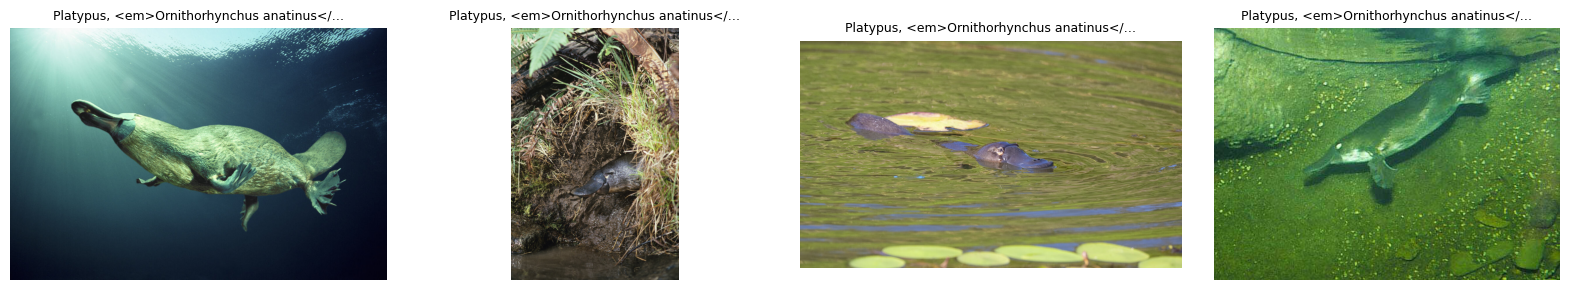

In [348]:
import math
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

UA = {"User-Agent": "MV-Jupyter/1.0 (contact: you@example.com)"}

def fetch_mv_images(max_images=12):
    images, captions = [], []

    # 1) Precise: the mammal Platypus by taxon name
    params_primary = {
        "recordtype": "species",
        "hasimages": "yes",
        "taxon": "Ornithorhynchus anatinus",
        "perpage": 100,
        "sort": "quality",
    }
    r = requests.get("https://collections.museumsvictoria.com.au/api/search",
                     params=params_primary, headers=UA, timeout=20)
    r.raise_for_status()
    data = r.json()

    def collect_media(records):
        for rec in records:
            for m in rec.get("media", []):
                if m.get("type") == "image":
                    # Prefer medium if available, else large/small
                    url = (
                        m.get("medium", {}) or
                        m.get("large", {}) or
                        m.get("small", {}) or
                        m.get("thumbnail", {})
                    ).get("uri")
                    if url:
                        images.append(url)
                        captions.append(m.get("caption") or rec.get("displayTitle") or "Platypus")
                if len(images) >= max_images:
                    return

    collect_media(data)

    # 2) Fallback: search by common name + constrain to mammals/monotremes
    if len(images) == 0:
        params_fallback = {
            "recordtype": "species",
            "hasimages": "yes",
            "query": "platypus",
            "taxon": "Mammalia,Monotremata",  # restrict to mammals/monotremes
            "perpage": 100,
            "sort": "quality",
        }
        r2 = requests.get("https://collections.museumsvictoria.com.au/api/search",
                          params=params_fallback, headers=UA, timeout=20)
        r2.raise_for_status()
        collect_media(r2.json())

    return images[:max_images], captions[:max_images]

imgs, caps = fetch_mv_images(max_images=8)

if not imgs:
    raise RuntimeError("No Platypus images found from Museums Victoria with current filters.")

# --- Display in a neat grid ---
cols = min(4, len(imgs))
rows = math.ceil(len(imgs) / cols)
plt.figure(figsize=(4*cols, 3*rows))
for i, (u, cap) in enumerate(zip(imgs, caps), start=1):
    ax = plt.subplot(rows, cols, i)
    im = Image.open(BytesIO(requests.get(u, headers=UA, timeout=20).content))
    ax.imshow(im)
    ax.axis("off")
    ax.set_title((cap or "Platypus")[:40] + ("…" if cap and len(cap) > 40 else ""), fontsize=9)
plt.tight_layout()
plt.show()


In [349]:
import requests
import pandas as pd

UA = {"User-Agent": "MV-Jupyter/1.0 (contact: you@example.com)"}

# Query Museums Victoria API for Platypus (species level)
params = {
    "recordtype": "species",
    "hasimages": "yes",
    "taxon": "Ornithorhynchus anatinus",
    "perpage": 50
}
url = "https://collections.museumsvictoria.com.au/api/search"

response = requests.get(url, params=params, headers=UA, timeout=20)
response.raise_for_status()
data = response.json()

# Extract image URLs
links = []
for rec in data:
    for m in rec.get("media", []):
        if m.get("type") == "image":
            url = (
                m.get("large", {}) or
                m.get("medium", {}) or
                m.get("small", {}) or
                m.get("thumbnail", {})
            ).get("uri")
            if url:
                links.append(url)

# Put into DataFrame
df = pd.DataFrame(links, columns=["image_url"])
df


,image_url
0,https://collections.museumsvictoria.com.au/con...
1,https://collections.museumsvictoria.com.au/con...
2,https://collections.museumsvictoria.com.au/con...
3,https://collections.museumsvictoria.com.au/con...


In [352]:
pd.set_option('display.max_colwidth', None)

In [353]:
df.head()


### animal/image_url

,image_url
0,https://collections.museumsvictoria.com.au/content/media/48/361498-large.jpg
1,https://collections.museumsvictoria.com.au/content/media/49/361499-large.jpg
2,https://collections.museumsvictoria.com.au/content/media/0/361500-large.jpg
3,https://collections.museumsvictoria.com.au/content/media/5/192105-large.jpg


In [354]:
df4.head()

,year,stateTerritory,ibraRegion,ScientificName,CommonName,Kingdom,griisStatus,capadStatus,EPBCThreatStatus,occurrenceCount,IBRA_REG_N,STATE,lat,lon,CommonName_clean
0,1900,NSW,Australian Alps,Ornithorhynchus anatinus,Platypus,Animalia,Native,PA,Present,1,Australian Alps,NSW,-36.074960,148.469095,Platypus
1,1900,NSW,Australian Alps,Pseudophryne corroboree,Southern Corroboree Frog,Animalia,Native,PA,Critically Endangered,6,Australian Alps,NSW,-36.074960,148.469095,Southern Corroboree Frog
2,1900,NSW,Brigalow Belt South,Ardeotis australis,Australian Bustard,Animalia,Native,not protected,Present,2,Brigalow Belt South,NSW,-30.762574,149.581615,Australian Bustard
3,1900,NSW,Brigalow Belt South,Chlamydera maculata,Spotted Bowerbird,Animalia,Native,not protected,Present,1,Brigalow Belt South,NSW,-30.762574,149.581615,Spotted Bowerbird
4,1900,NSW,Brigalow Belt South,Hemiaspis damelii,Grey Snake,Animalia,Native,not protected,Endangered,3,Brigalow Belt South,NSW,-30.762574,149.581615,Grey Snake


In [359]:
pairs = (
    df4[["ScientificName", "CommonName_clean"]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={"CommonName_clean": "CommonName"})
)

In [363]:
import requests
import pandas as pd

# Example species pairs (replace with your df 'pairs')
# pairs = pd.DataFrame({
#     "ScientificName": [
#         "Ornithorhynchus anatinus",
#         "Pseudophryne corroboree",
#         "Ardeotis australis"
#     ],
#     "CommonName": [
#         "Platypus",
#         "Southern Corroboree Frog",
#         "Australian Bustard"
#     ]
# })


pairs = (
    df4[["ScientificName", "CommonName_clean"]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={"CommonName_clean": "CommonName"})
)

UA = {"User-Agent": "MV-Jupyter/1.0 (contact: you@example.com)"}
url = "https://collections.museumsvictoria.com.au/api/search"

import time
from tqdm import tqdm  # pip install tqdm

def get_first_image(scientific_name):
    params = {"recordtype": "species", "hasimages": "yes", "taxon": scientific_name, "perpage": 1}
    try:
        r = requests.get(url, params=params, headers=UA, timeout=15)
        r.raise_for_status()
        data = r.json()
        if data and "media" in data[0]:
            for m in data[0]["media"]:
                if m.get("type") == "image":
                    return (
                        m.get("large", {}) or
                        m.get("medium", {}) or
                        m.get("small", {}) or
                        m.get("thumbnail", {})
                    ).get("uri")
    except:
        return None
    return None

# loop with progress + throttle
results = []
for name in tqdm(pairs["ScientificName"], desc="Fetching images"):
    results.append(get_first_image(name))
    time.sleep(0.2)  # 5 requests per second (adjust if needed)

pairs["image_url"] = results


Fetching images: 100%|██████████████████████| 1275/1275 [09:13<00:00,  2.30it/s]


In [371]:
pairs.shape

(1275, 3)

In [372]:
pairs.head()

,ScientificName,CommonName,image_url
0,Ornithorhynchus anatinus,Platypus,https://collections.museumsvictoria.com.au/content/media/48/361498-large.jpg
1,Pseudophryne corroboree,Southern Corroboree Frog,None
2,Ardeotis australis,Australian Bustard,https://collections.museumsvictoria.com.au/content/media/34/1019784-large.jpg
3,Chlamydera maculata,Spotted Bowerbird,None
4,Hemiaspis damelii,Grey Snake,None


In [373]:
import time
import requests
import pandas as pd
from tqdm import tqdm  # pip install tqdm

# Assumes you already built `pairs` as in your snippet:
pairs = (
    df4[["ScientificName", "CommonName_clean"]]
      .dropna(subset=["ScientificName"])
      .drop_duplicates()
      .rename(columns={"CommonName_clean": "CommonName"})
)

UA = {"User-Agent": "Jupyter-iNat/1.0 (contact: you@example.com)"}

def _best_url_from_default_photo(default_photo: dict):
    """Pick a good, directly accessible size from iNat default_photo."""
    if not default_photo:
        return None
    # Prefer large/original, then medium
    for key in ("large_url", "original_url", "medium_url", "url"):
        if default_photo.get(key):
            return default_photo[key]
    return None

def _best_url_from_photo_obj(photo: dict):
    """Pick an accessible URL from a photo object in observations."""
    if not photo:
        return None
    # iNat observation photos usually have 'url' with a size word we can keep as-is
    # or switch to a larger size by replacing 'square'/'small' with 'medium'/'large'.
    url = photo.get("url") or photo.get("medium_url") or photo.get("large_url") or photo.get("original_url")
    if not url:
        return None
    # Try to get a larger but still public derivative
    return (url
            .replace("square", "large")
            .replace("small", "large")
            .replace("medium", "large"))

def get_first_inat_image(scientific_name: str, sleep_sec: float = 0.25):
    """
    Return a single accessible image URL for the given species, using iNaturalist.
    1) Try /v1/taxa for the species and take default_photo (stable & accessible).
    2) If none, try /v1/observations?taxon_name=... and take first photo.
    """
    # 1) Taxa default photo
    try:
        resp = requests.get(
            "https://api.inaturalist.org/v1/taxa",
            params={"q": scientific_name, "rank": "species", "per_page": 1},
            headers=UA, timeout=20
        )
        resp.raise_for_status()
        j = resp.json()
        if j.get("results"):
            default_photo = j["results"][0].get("default_photo")
            url = _best_url_from_default_photo(default_photo)
            if url:
                time.sleep(sleep_sec)
                return url
    except Exception:
        pass

    # 2) Observation photo fallback (recent, high-likelihood of accessibility)
    try:
        resp2 = requests.get(
            "https://api.inaturalist.org/v1/observations",
            params={
                "taxon_name": scientific_name,
                "photos": "true",
                "per_page": 1,
                "order": "desc",
                "order_by": "created_at",
                # Optional: restrict to 'research' grade; comment out if you want broader coverage
                # "quality_grade": "research"
            },
            headers=UA, timeout=20
        )
        resp2.raise_for_status()
        j2 = resp2.json()
        if j2.get("results"):
            photos = j2["results"][0].get("photos") or []
            if photos:
                url = _best_url_from_photo_obj(photos[0])
                if url:
                    time.sleep(sleep_sec)
                    return url
    except Exception:
        pass

    time.sleep(sleep_sec)
    return None

# Fetch URLs with a polite throttle
image_urls = []
for sci in tqdm(pairs["ScientificName"], desc="Fetching iNat images"):
    image_urls.append(get_first_inat_image(sci, sleep_sec=0.25))

pairs_inat = pairs.copy()
pairs_inat["image_url"] = image_urls

# Show the result
pairs_inat


Fetching iNat images: 100%|█████████████████| 1275/1275 [27:35<00:00,  1.30s/it]


,ScientificName,CommonName,image_url
0,Ornithorhynchus anatinus,Platypus,https://static.inaturalist.org/photos/100089852/medium.jpg
1,Pseudophryne corroboree,Southern Corroboree Frog,https://static.inaturalist.org/photos/344976454/medium.jpeg
2,Ardeotis australis,Australian Bustard,https://inaturalist-open-data.s3.amazonaws.com/photos/188955284/medium.jpg
3,Chlamydera maculata,Spotted Bowerbird,https://inaturalist-open-data.s3.amazonaws.com/photos/356245224/medium.jpg
4,Hemiaspis damelii,Grey Snake,https://static.inaturalist.org/photos/388840133/medium.jpg
5,Oreoica gutturalis,Crested Bellbird,https://inaturalist-open-data.s3.amazonaws.com/photos/43977723/medium.jpg
6,Phascolarctos cinereus,Koala,https://inaturalist-open-data.s3.amazonaws.com/photos/446727684/medium.jpeg
7,Pomatostomus temporalis,Grey-crowned Babbler,https://inaturalist-open-data.s3.amazonaws.com/photos/233704779/medium.jpg
8,Vermicella annulata,Bandy Bandy (snake),https://static.inaturalist.org/photos/287163324/medium.jpg
10,Leipoa ocellata,Malleefowl,https://inaturalist-open-data.s3.amazonaws.com/photos/71922706/medium.jpeg


In [375]:
pairs_inat.isna().sum()

ScientificName      0
CommonName          5
image_url         217
dtype: int64